# Smart Home Energy Simulation

This notebook provides an interactive object-oriented model for energy simulation. You can define components like PV systems, batteries, and heat pumps, and then run simulations to analyze energy balance and costs.

## 1. Simulation Logic
Define the base classes for components and the simulation engine.

In [1]:
import importlib, simulation
importlib.reload(simulation)
from simulation import *
import pandas as pd, numpy as np
print('simulation.py loaded.')


simulation.py loaded.


## 2. Setup & Run Baseline
Initialize and execute the **Base Case**.

In [2]:
from simulation import setup_base, run_scenario, show_comparison
import pandas as pd, numpy as np

# Default duration — old scenario cells (Cell 6/8) use these variables.
# They get overridden when run_scenario() is called with explicit duration_days.
duration_days = 1
steps_per_day = 4
dt            = 24.0 / steps_per_day
total_steps   = steps_per_day * duration_days

print(f'Ready. Default: {duration_days} day(s), {total_steps} steps x {dt:.1f} h each.')


Ready. Default: 1 day(s), 4 steps x 6.0 h each.


## 3. Scenario Adjustment
Define multipliers for the scenario.

In [3]:
pv_factor = 0.0     # 0% PV (no solar available)
battery_factor = 0.2 # 80% reduction
print(f"FACTORS: PV x{pv_factor}, Battery x{battery_factor}")

FACTORS: PV x0.0, Battery x0.2


## 4. Run Scenario
Execute the simulation with the adjusted parameters.

In [4]:
# ── First Scenario (no PV, reduced battery) ──────────────────
base_summary, scenario_summary = run_scenario(
    duration_days  = duration_days,
    season         = 'winter',
    pv_factor      = pv_factor,
    battery_factor = battery_factor,
)
print(f'SCENARIO RUN: {duration_days} day(s)')
for k, v in scenario_summary.items(): print(f'  {k:28}: {v:8.2f}')



--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=2.0    MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------

SCENARIO RUN: 1 day(s)
  Total Cost (CHF)            :    12.84
  PV Generation (kWh)         :     0.00
  Heat Demand (kWh)           :    69.00
  Heat Supplied (kWh)         :    69.00
  Cooling Demand (kWh)        :     0.00
  Cooling Supplied (kWh)      :     0.00
  Elec Demand (kWh)           :    45.00
  Elec Supplied (kWh)         :    45.00
  Grid Import (kWh)           :   

## 5. Comparison Matrix
Visualize the analytics: **SCR** (Self-Consumption), **SSR** (Self-Sufficiency), and **Comfort**.

In [5]:
import pandas as pd, numpy as np

def calculate_comp(base, scen):
    res = []
    for m in base:
        b, s = base[m], scen[m]
        dev = ((s-b)/abs(b)*100) if b != 0 else (0.0 if s == 0 else float('nan'))
        res.append({'Metric': m, 'Base': b, 'Scenario': s, 'Rel. Dev. (%)': dev})
    return pd.DataFrame(res)

def color_dev(v):
    if pd.isna(v) or v == 0: return 'background-color:#3b82f6;color:white'
    return 'background-color:#22c55e;color:white' if v > 0 else 'background-color:#ef4444;color:white'

def show_comparison(base, scen, title='Comparison'):
    print(f'--- {title} ---')
    df = calculate_comp(base, scen)
    return df.style.map(color_dev, subset=['Rel. Dev. (%)']).format(
        {'Base': '{:.2f}', 'Scenario': '{:.2f}', 'Rel. Dev. (%)': '{:+.2f}%'})


## Heat Wave
set parameters to Heat Wave Scneario.

Studies show that for a typical Heatwave in the worst case Scenario PV performance drops by up to 30%. further investigation showed that cooling demand will rise and could increase ba up to 100%. While the increased Temperature would theoretically increase hp performance, we will not inclulde because heating does not play a role in Summer. 

Batteries and heat storage do not play a role since we assume they are isolated from external factors. Base electricity demand is not affected aswell and we assume no interference in the grid.

In [6]:
# ════════════════════════════════════════════════════════════
# SCENARIO  —  edit values, then run this cell
# ════════════════════════════════════════════════════════════
sweep_results_hw = run_pv_sweep_scenario(
    duration_days           = 30,
    season                  = 'summer',  # <--- set season to summer
    pv_factor               = 0.70,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 2.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)



RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=4.0   
PV          : Capacity=3.345263157894737 Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=4.0   
PV          : Capacity=2.787719298245614 Effi


--- Heatwave vs Base ---

PV Sizing: 1.2x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),-18.52,141.26,+159.79,+862.62%
1,PV Generation (kWh),1634.40,1144.08,-490.32,-30.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,2880.00,+1440.00,+100.00%
5,Cooling Supplied (kWh),1440.00,2340.00,+900.00,+62.50%
6,Elec Demand (kWh),1365.50,1665.50,+300.00,+21.97%
7,Elec Supplied (kWh),1365.50,1665.50,+300.00,+21.97%
8,Grid Import (kWh),2.64,523.20,+520.56,+19696.70%
9,Grid Export (kWh),240.46,0.00,-240.46,-100.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),9.13,190.36,+181.24,+1986.03%
1,PV Generation (kWh),1362.00,953.40,-408.60,-30.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,2880.00,+1440.00,+100.00%
5,Cooling Supplied (kWh),1440.00,2340.00,+900.00,+62.50%
6,Elec Demand (kWh),1365.50,1664.15,+298.65,+21.87%
7,Elec Supplied (kWh),1365.50,1664.15,+298.65,+21.87%
8,Grid Import (kWh),33.80,705.05,+671.25,+1986.03%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),75.89,242.02,+166.13,+218.92%
1,PV Generation (kWh),1089.60,762.72,-326.88,-30.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,2880.00,+1440.00,+100.00%
5,Cooling Supplied (kWh),1440.00,2340.00,+900.00,+62.50%
6,Elec Demand (kWh),1365.50,1664.78,+299.29,+21.92%
7,Elec Supplied (kWh),1365.50,1664.78,+299.29,+21.92%
8,Grid Import (kWh),281.06,896.36,+615.30,+218.92%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),145.75,292.99,+147.24,+101.02%
1,PV Generation (kWh),817.20,572.04,-245.16,-30.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,2880.00,+1440.00,+100.00%
5,Cooling Supplied (kWh),1440.00,2340.00,+900.00,+62.50%
6,Elec Demand (kWh),1362.72,1662.89,+300.17,+22.03%
7,Elec Supplied (kWh),1362.72,1662.89,+300.17,+22.03%
8,Grid Import (kWh),539.82,1085.15,+545.33,+101.02%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),141.26,190.36,242.02,292.99
12,PV Generation (kWh),1144.08,953.40,762.72,572.04
10,Heat Demand (kWh),252.00,252.00,252.00,252.00
11,Heat Supplied (kWh),252.00,252.00,252.00,252.00
1,Cooling Demand (kWh),2880.00,2880.00,2880.00,2880.00
2,Cooling Supplied (kWh),2340.00,2340.00,2340.00,2340.00
4,Elec Demand (kWh),1665.50,1664.15,1664.78,1662.89
5,Elec Supplied (kWh),1665.50,1664.15,1664.78,1662.89
8,Grid Import (kWh),523.20,705.05,896.36,1085.15
7,Grid Export (kWh),0.00,0.00,0.00,0.00


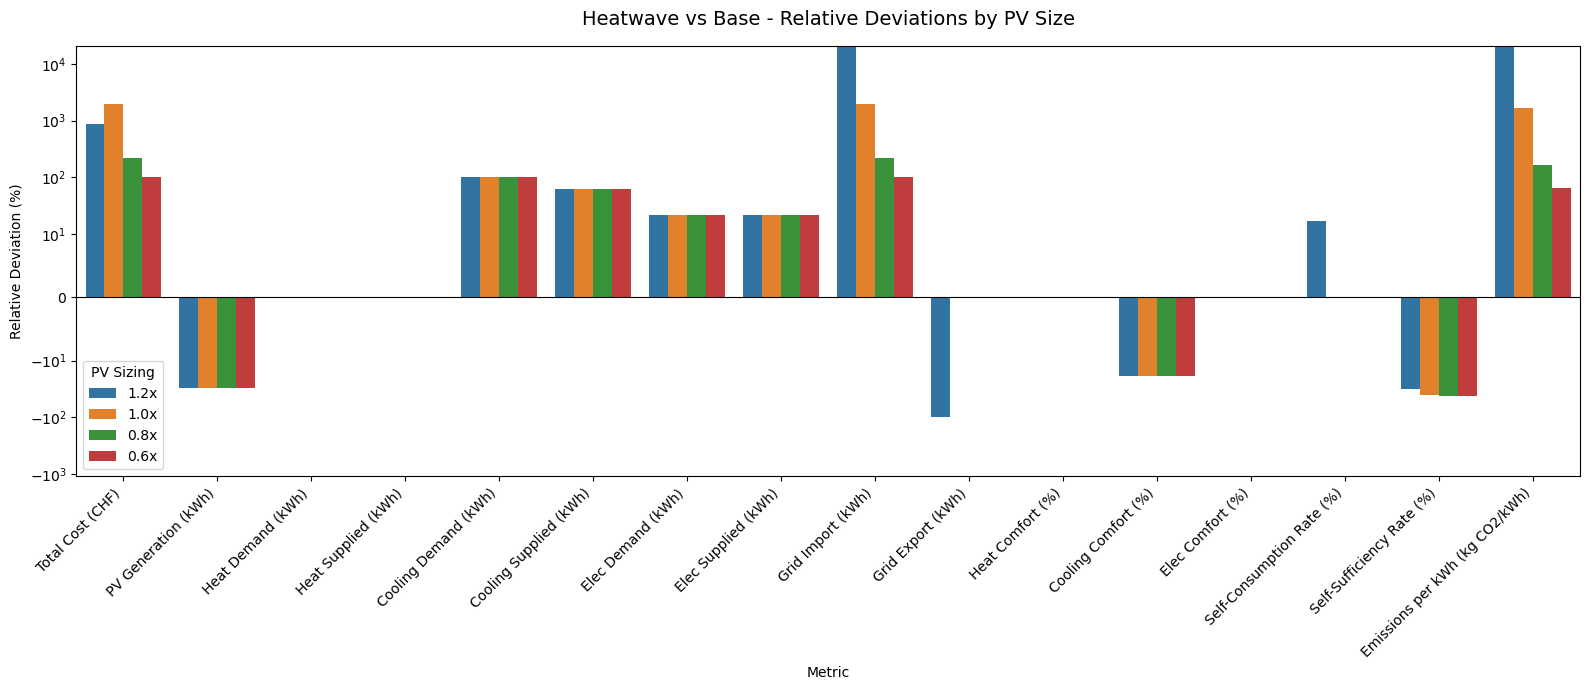

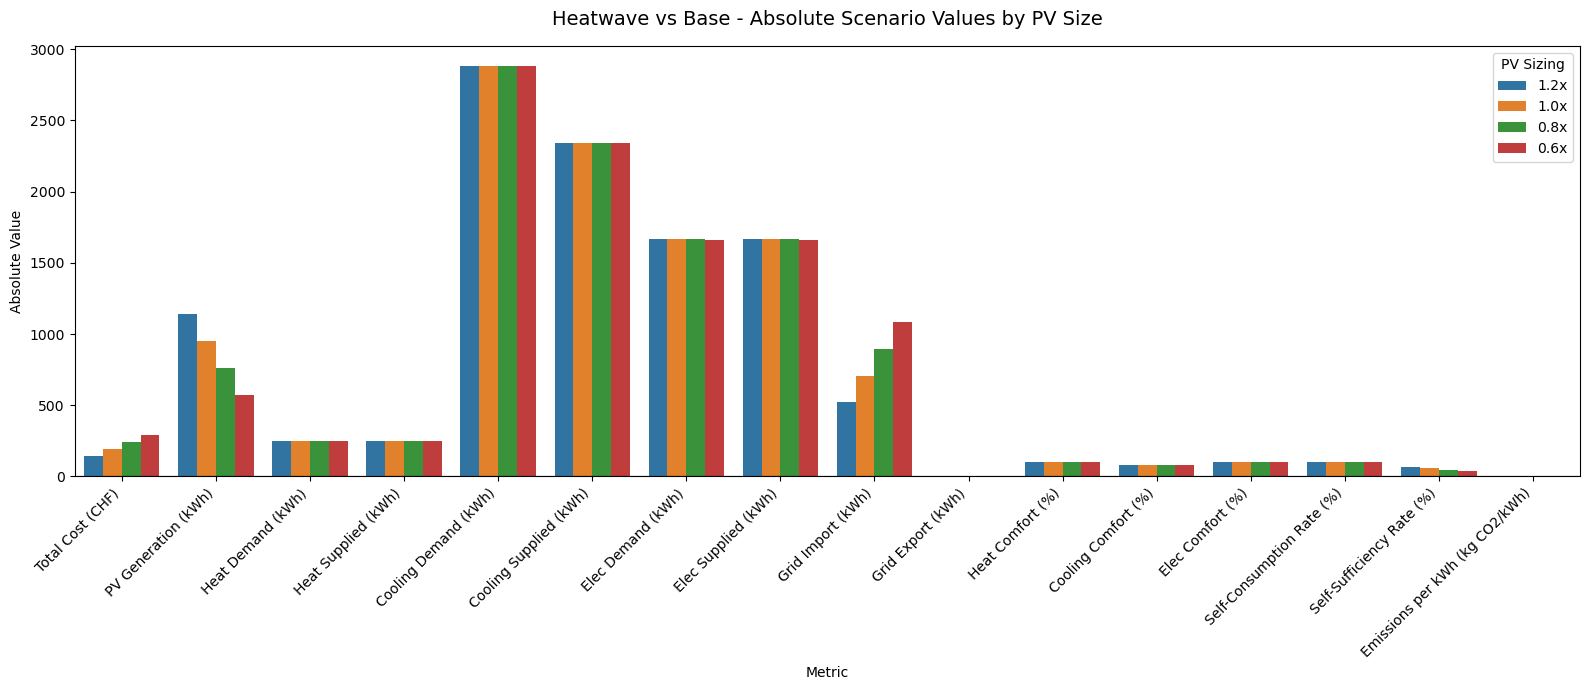

In [7]:
show_sweep_comparison(sweep_results_hw, 'Heatwave vs Base')


## Heat Wave combined with Wildfire

Heat wave often come in hand with droughts and wild fires and especially in the futre are projected to happen more often. Studies show that increase in PV temperature combined with dustcollection and cloudy weather caused by wildfires can reduce PV output by upto 60%. 

The rest is assumed to stay the same.


RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=4.0   
PV          : Capacity=1.9115789473684215 Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=4.0   
PV          : Capacity=1.5929824561403512 Ef

,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),-3.49,62.51,+65.99,+1893.33%
1,PV Generation (kWh),381.36,152.54,-228.82,-60.00%
2,Heat Demand (kWh),58.80,58.80,+0.00,+0.00%
3,Heat Supplied (kWh),58.80,58.80,+0.00,+0.00%
4,Cooling Demand (kWh),336.00,672.00,+336.00,+100.00%
5,Cooling Supplied (kWh),336.00,546.00,+210.00,+62.50%
6,Elec Demand (kWh),321.30,389.76,+68.46,+21.31%
7,Elec Supplied (kWh),321.30,389.76,+68.46,+21.31%
8,Grid Import (kWh),2.64,231.51,+228.87,+8659.88%
9,Grid Export (kWh),52.49,0.00,-52.49,-100.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),3.17,68.93,+65.75,+2072.38%
1,PV Generation (kWh),317.80,127.12,-190.68,-60.00%
2,Heat Demand (kWh),58.80,58.80,+0.00,+0.00%
3,Heat Supplied (kWh),58.80,58.80,+0.00,+0.00%
4,Cooling Demand (kWh),336.00,672.00,+336.00,+100.00%
5,Cooling Supplied (kWh),336.00,546.00,+210.00,+62.50%
6,Elec Demand (kWh),321.30,388.11,+66.81,+20.79%
7,Elec Supplied (kWh),321.30,388.11,+66.81,+20.79%
8,Grid Import (kWh),11.75,255.29,+243.53,+2072.38%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),17.32,75.71,+58.39,+337.14%
1,PV Generation (kWh),254.24,101.70,-152.54,-60.00%
2,Heat Demand (kWh),58.80,58.80,+0.00,+0.00%
3,Heat Supplied (kWh),58.80,58.80,+0.00,+0.00%
4,Cooling Demand (kWh),336.00,672.00,+336.00,+100.00%
5,Cooling Supplied (kWh),336.00,546.00,+210.00,+62.50%
6,Elec Demand (kWh),321.30,387.80,+66.50,+20.70%
7,Elec Supplied (kWh),321.30,387.80,+66.50,+20.70%
8,Grid Import (kWh),64.14,280.40,+216.26,+337.14%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),32.98,82.57,+49.60,+150.40%
1,PV Generation (kWh),190.68,76.27,-114.41,-60.00%
2,Heat Demand (kWh),58.80,58.80,+0.00,+0.00%
3,Heat Supplied (kWh),58.80,58.80,+0.00,+0.00%
4,Cooling Demand (kWh),336.00,672.00,+336.00,+100.00%
5,Cooling Supplied (kWh),336.00,546.00,+210.00,+62.50%
6,Elec Demand (kWh),318.52,387.80,+69.28,+21.75%
7,Elec Supplied (kWh),318.52,387.80,+69.28,+21.75%
8,Grid Import (kWh),122.14,305.83,+183.69,+150.40%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),62.51,68.93,75.71,82.57
12,PV Generation (kWh),152.54,127.12,101.70,76.27
10,Heat Demand (kWh),58.80,58.80,58.80,58.80
11,Heat Supplied (kWh),58.80,58.80,58.80,58.80
1,Cooling Demand (kWh),672.00,672.00,672.00,672.00
2,Cooling Supplied (kWh),546.00,546.00,546.00,546.00
4,Elec Demand (kWh),389.76,388.11,387.80,387.80
5,Elec Supplied (kWh),389.76,388.11,387.80,387.80
8,Grid Import (kWh),231.51,255.29,280.40,305.83
7,Grid Export (kWh),0.00,0.00,0.00,0.00


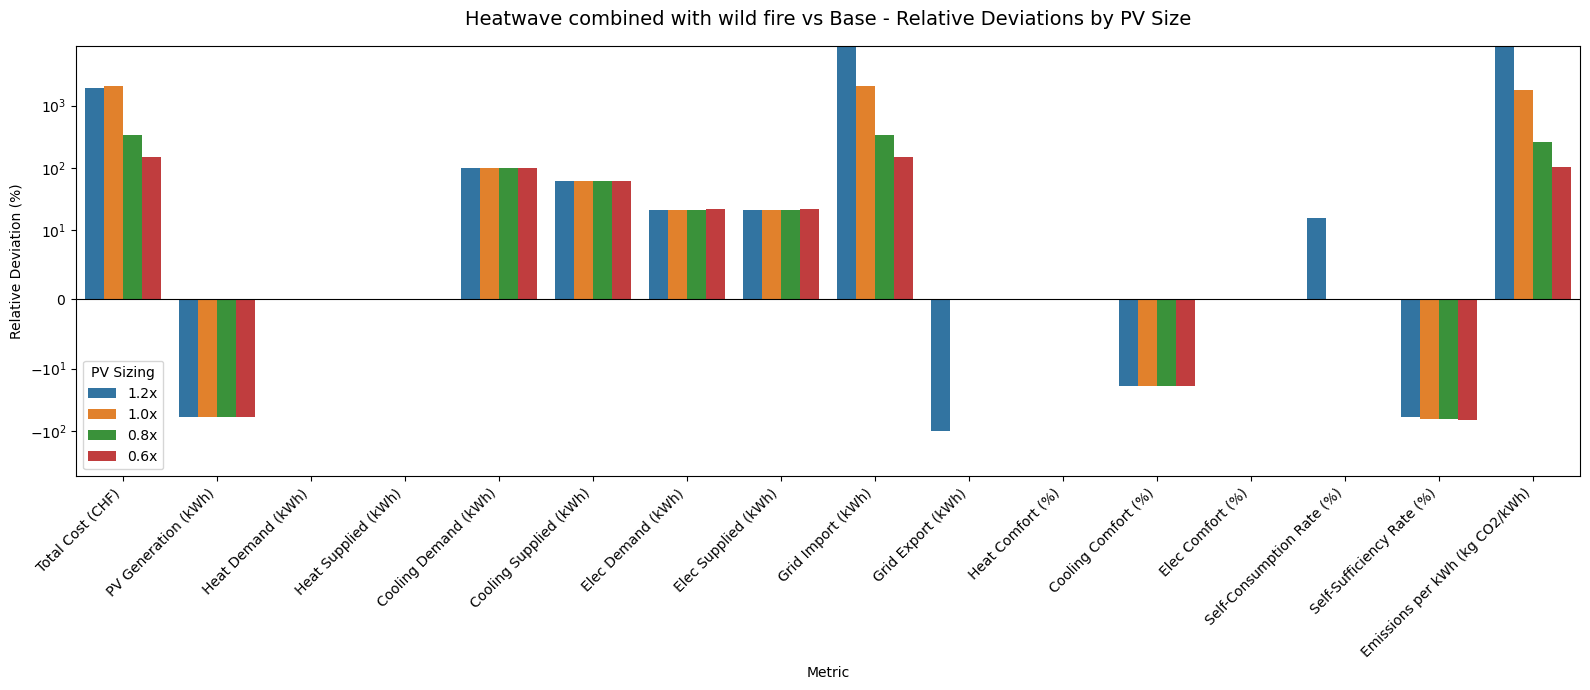

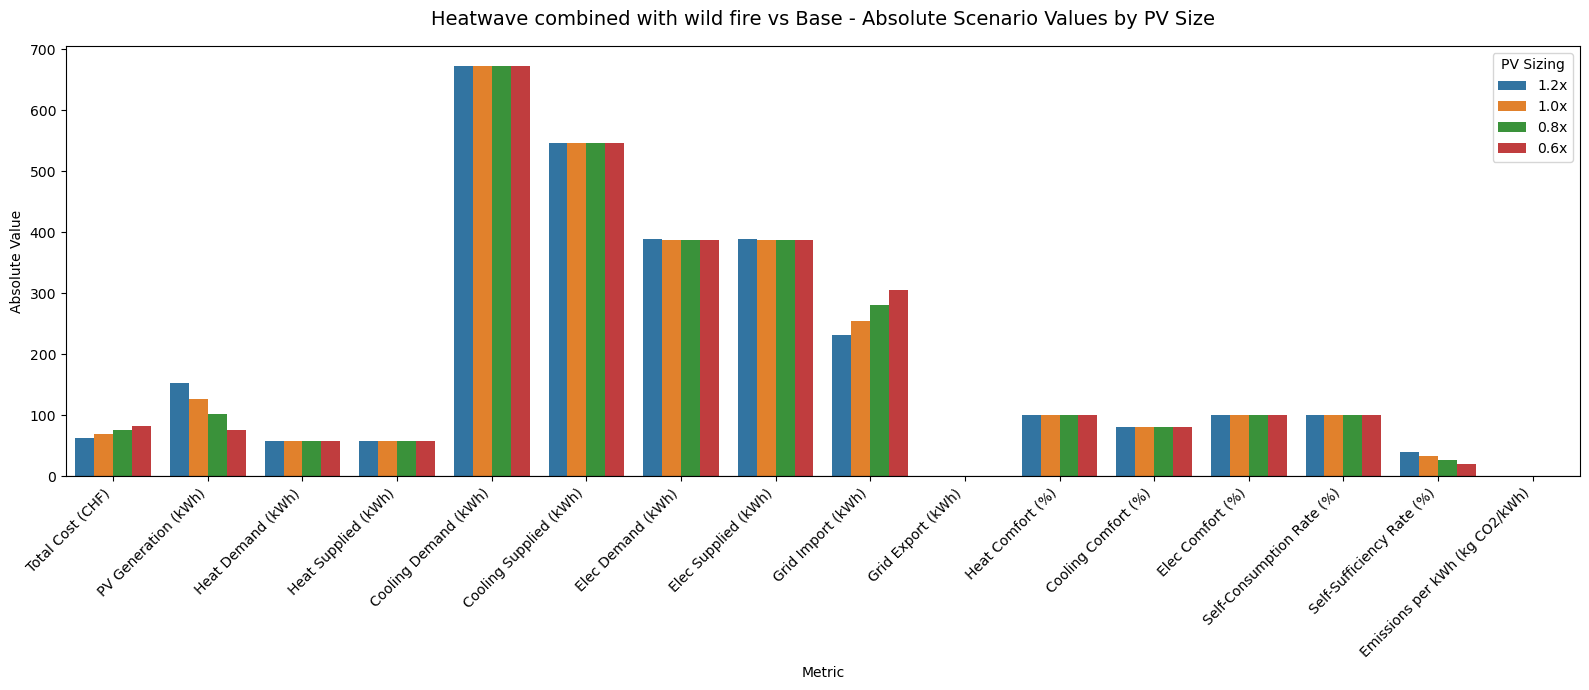

In [8]:
# ════════════════════════════════════════════════════════════
# SCENARIO  —  edit values, then run this cell
# ════════════════════════════════════════════════════════════
sweep_results_hw_wild_fire  = run_pv_sweep_scenario(
    duration_days           = 7,
    season                  = 'summer',  # <--- set season to summer
    pv_factor               = 0.40,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 2.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)

show_sweep_comparison(sweep_results_hw_wild_fire, 'Heatwave combined with wild fire vs Base')


## Heatwave combined with Blackout

now we assume standart heatwave but due to human error or natural hazard a blackout has been caused. To simplify we assume we can still feed in electricity into the grid or burn it of somewhere else (e.g. Smart meter gives signal to ramp up A/C).


RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=4.0   
PV          : Capacity=3.345263157894737 Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=4.0   
PV          : Capacity=2.787719298245614 Effi

,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),-0.87,0.00,+0.87,+100.00%
1,PV Generation (kWh),163.44,114.41,-49.03,-30.00%
2,Heat Demand (kWh),25.20,25.20,+0.00,+0.00%
3,Heat Supplied (kWh),25.20,25.20,+0.00,+0.00%
4,Cooling Demand (kWh),144.00,288.00,+144.00,+100.00%
5,Cooling Supplied (kWh),144.00,234.00,+90.00,+62.50%
6,Elec Demand (kWh),139.70,169.70,+30.00,+21.47%
7,Elec Supplied (kWh),139.70,119.36,-20.34,-14.56%
8,Grid Import (kWh),2.64,0.00,-2.64,-100.00%
9,Grid Export (kWh),19.80,0.00,-19.80,-100.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),2.14,0.00,-2.14,-100.00%
1,PV Generation (kWh),136.20,95.34,-40.86,-30.00%
2,Heat Demand (kWh),25.20,25.20,+0.00,+0.00%
3,Heat Supplied (kWh),25.20,25.20,+0.00,+0.00%
4,Cooling Demand (kWh),144.00,288.00,+144.00,+100.00%
5,Cooling Supplied (kWh),144.00,234.00,+90.00,+62.50%
6,Elec Demand (kWh),139.70,168.35,+28.65,+20.51%
7,Elec Supplied (kWh),139.70,101.04,-38.66,-27.67%
8,Grid Import (kWh),7.92,0.00,-7.92,-100.00%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),7.13,0.00,-7.13,-100.00%
1,PV Generation (kWh),108.96,76.27,-32.69,-30.00%
2,Heat Demand (kWh),25.20,25.20,+0.00,+0.00%
3,Heat Supplied (kWh),25.20,25.20,+0.00,+0.00%
4,Cooling Demand (kWh),144.00,288.00,+144.00,+100.00%
5,Cooling Supplied (kWh),144.00,234.00,+90.00,+62.50%
6,Elec Demand (kWh),139.70,168.98,+29.29,+20.96%
7,Elec Supplied (kWh),139.70,81.97,-57.73,-41.32%
8,Grid Import (kWh),26.42,0.00,-26.42,-100.00%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),13.36,0.00,-13.36,-100.00%
1,PV Generation (kWh),81.72,57.20,-24.52,-30.00%
2,Heat Demand (kWh),25.20,25.20,+0.00,+0.00%
3,Heat Supplied (kWh),25.20,25.20,+0.00,+0.00%
4,Cooling Demand (kWh),144.00,288.00,+144.00,+100.00%
5,Cooling Supplied (kWh),144.00,234.00,+90.00,+62.50%
6,Elec Demand (kWh),136.92,167.09,+30.17,+22.04%
7,Elec Supplied (kWh),136.92,62.90,-74.01,-54.06%
8,Grid Import (kWh),49.50,0.00,-49.50,-100.00%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),0.00,0.00,0.00,0.00
12,PV Generation (kWh),114.41,95.34,76.27,57.20
10,Heat Demand (kWh),25.20,25.20,25.20,25.20
11,Heat Supplied (kWh),25.20,25.20,25.20,25.20
1,Cooling Demand (kWh),288.00,288.00,288.00,288.00
2,Cooling Supplied (kWh),234.00,234.00,234.00,234.00
4,Elec Demand (kWh),169.70,168.35,168.98,167.09
5,Elec Supplied (kWh),119.36,101.04,81.97,62.90
8,Grid Import (kWh),0.00,0.00,0.00,0.00
7,Grid Export (kWh),0.00,0.00,0.00,0.00


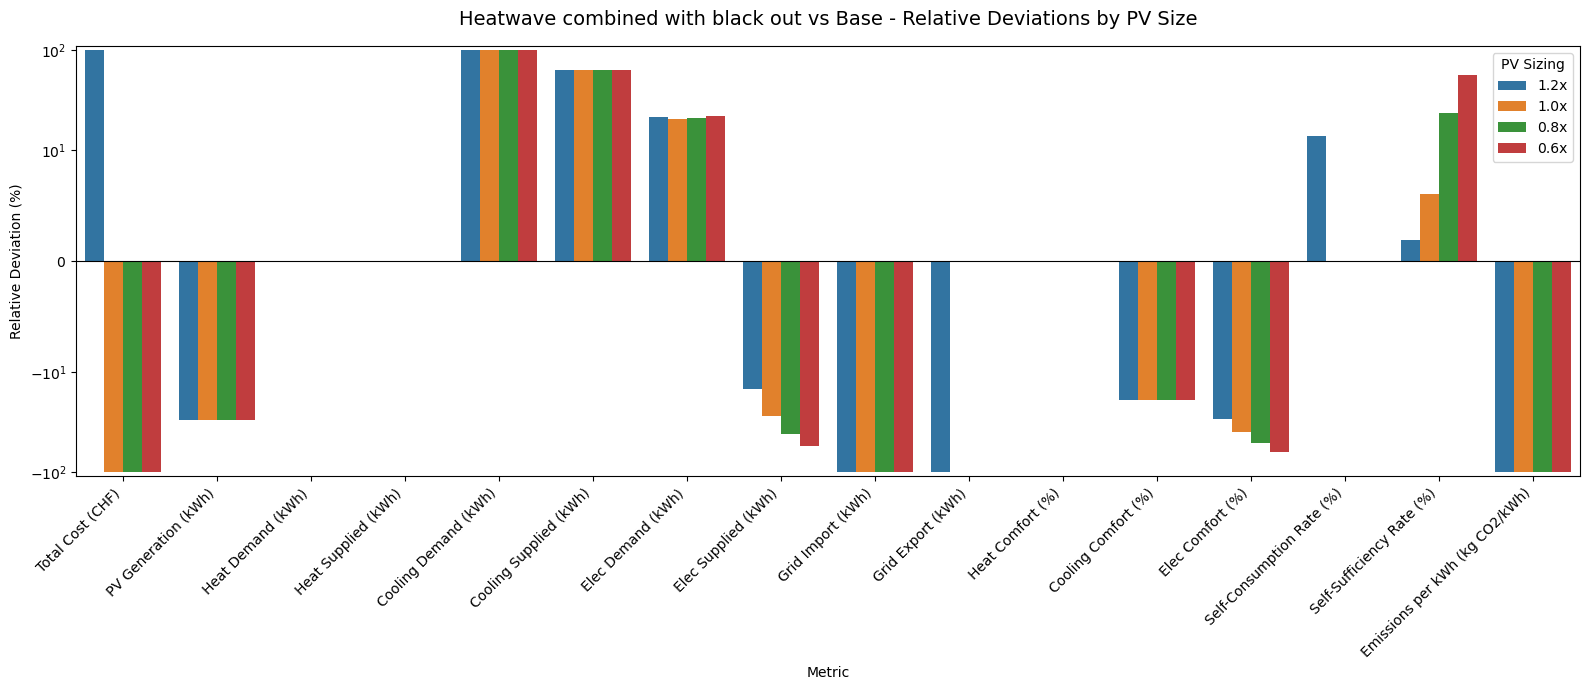

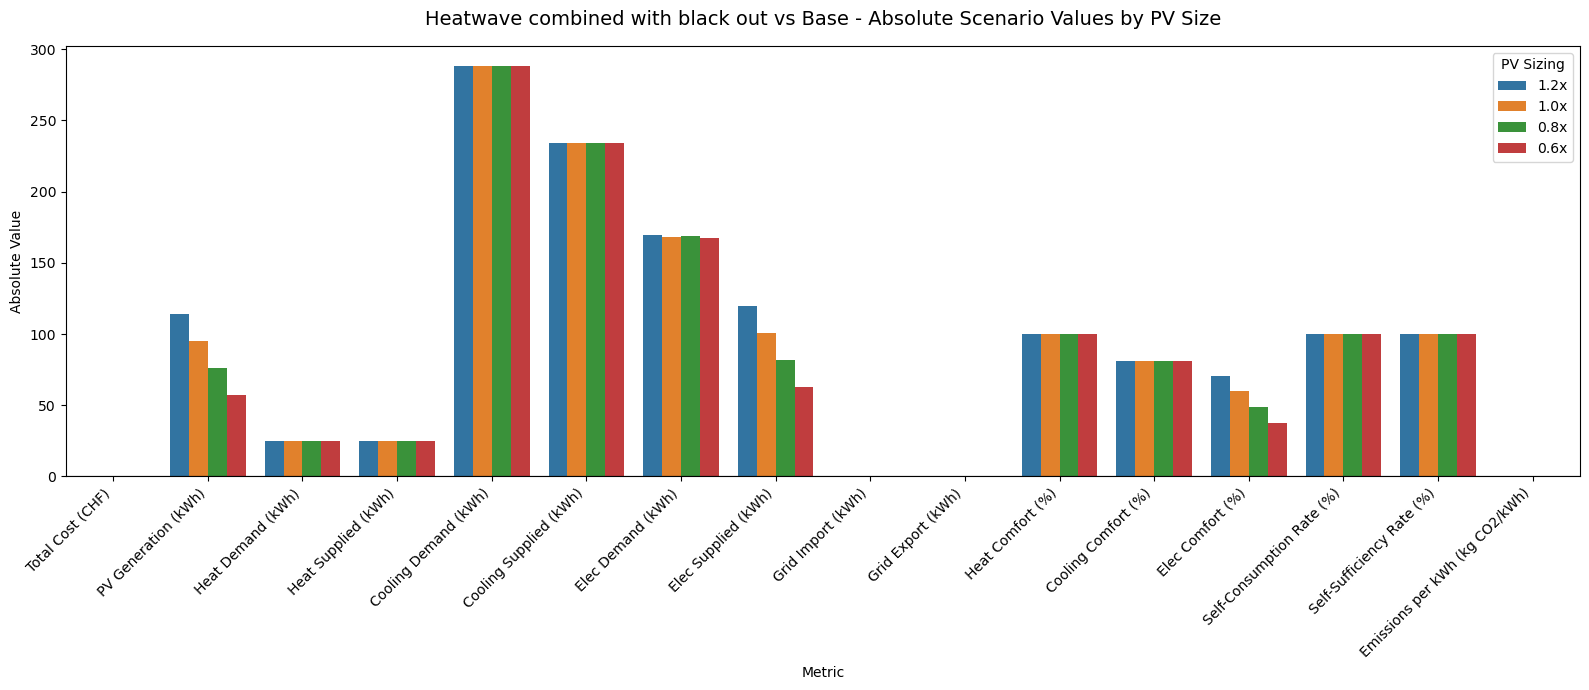

In [9]:
# ════════════════════════════════════════════════════════════
# SCENARIO  —  edit values, then run this cell
# ════════════════════════════════════════════════════════════
sweep_results_hw_bo  = run_pv_sweep_scenario(
    duration_days           = 3,
    season                  = 'summer',  # <--- set season to summer
    pv_factor               = 0.70,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 2.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = True,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)

show_sweep_comparison(sweep_results_hw_bo, 'Heatwave combined with black out vs Base')


## Cold Spell Scenario
Set parameters for a cold spell event (low temperatures, high heat demand, reduced PV).

Cold spells are compared to a winterscenario where we already have higher demand and lower irradiation from the sun.


In [21]:
# ════════════════════════════════════════════════════════════
# COLD SPELL SCENARIO  —  edit values, then run this cell
# ════════════════════════════════════════════════════════════
sweep_results_cs = run_pv_sweep_scenario(
    duration_days           = 4,     # e.g. 4-day cold spell
    season                  = 'winter',  # <--- set season to winter
    pv_factor               = 1.0,   # less sun in winter
    battery_factor          = 1.0,
    heat_demand_factor      = 1.2,   # 1.2x heat demand
    cooling_demand_factor   = 0.0,   # no cooling needed
    elec_demand_factor      = 1.0,   # slightly more elec (lights etc.)
    hp_capacity_factor      = 0.5,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)



RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=3.4499999999999997
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=7.186813186813186 Efficiency=1.0   
HeatPump    : Capacity=1.5    Efficiency=1.75  
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=3.4499999999999997
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacit

### Cold Spell Comparison Matrix


--- Cold Spell vs Base ---

PV Sizing: 1.2x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),4.59,64.65,+60.06,+1308.58%
1,PV Generation (kWh),224.23,224.23,+0.00,+0.00%
2,Heat Demand (kWh),276.00,552.00,+276.00,+100.00%
3,Heat Supplied (kWh),276.00,518.94,+242.94,+88.02%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),180.86,190.29,+9.43,+5.21%
7,Elec Supplied (kWh),180.86,190.29,+9.43,+5.21%
8,Grid Import (kWh),20.41,27.26,+6.86,+33.60%
9,Grid Export (kWh),61.50,58.93,-2.57,-4.18%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),7.93,67.99,+60.06,+757.21%
1,PV Generation (kWh),186.86,186.86,+0.00,+0.00%
2,Heat Demand (kWh),276.00,552.00,+276.00,+100.00%
3,Heat Supplied (kWh),276.00,518.94,+242.94,+88.02%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),180.86,190.29,+9.43,+5.21%
7,Elec Supplied (kWh),180.86,190.29,+9.43,+5.21%
8,Grid Import (kWh),22.56,29.42,+6.86,+30.39%
9,Grid Export (kWh),27.01,24.44,-2.57,-9.52%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),12.39,72.66,+60.27,+486.45%
1,PV Generation (kWh),149.49,149.49,+0.00,+0.00%
2,Heat Demand (kWh),276.00,552.00,+276.00,+100.00%
3,Heat Supplied (kWh),276.00,518.94,+242.94,+88.02%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),180.86,190.29,+9.43,+5.21%
7,Elec Supplied (kWh),180.86,190.29,+9.43,+5.21%
8,Grid Import (kWh),31.07,39.48,+8.40,+27.05%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),21.42,81.89,+60.48,+282.39%
1,PV Generation (kWh),112.11,112.11,+0.00,+0.00%
2,Heat Demand (kWh),276.00,552.00,+276.00,+100.00%
3,Heat Supplied (kWh),276.00,518.94,+242.94,+88.02%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),180.86,190.29,+9.43,+5.21%
7,Elec Supplied (kWh),180.86,190.29,+9.43,+5.21%
8,Grid Import (kWh),64.50,73.68,+9.18,+14.23%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),64.65,67.99,72.66,81.89
12,PV Generation (kWh),224.23,186.86,149.49,112.11
10,Heat Demand (kWh),552.00,552.00,552.00,552.00
11,Heat Supplied (kWh),518.94,518.94,518.94,518.94
1,Cooling Demand (kWh),0.00,0.00,0.00,0.00
2,Cooling Supplied (kWh),0.00,0.00,0.00,0.00
4,Elec Demand (kWh),190.29,190.29,190.29,190.29
5,Elec Supplied (kWh),190.29,190.29,190.29,190.29
8,Grid Import (kWh),27.26,29.42,39.48,73.68
7,Grid Export (kWh),58.93,24.44,0.00,0.00


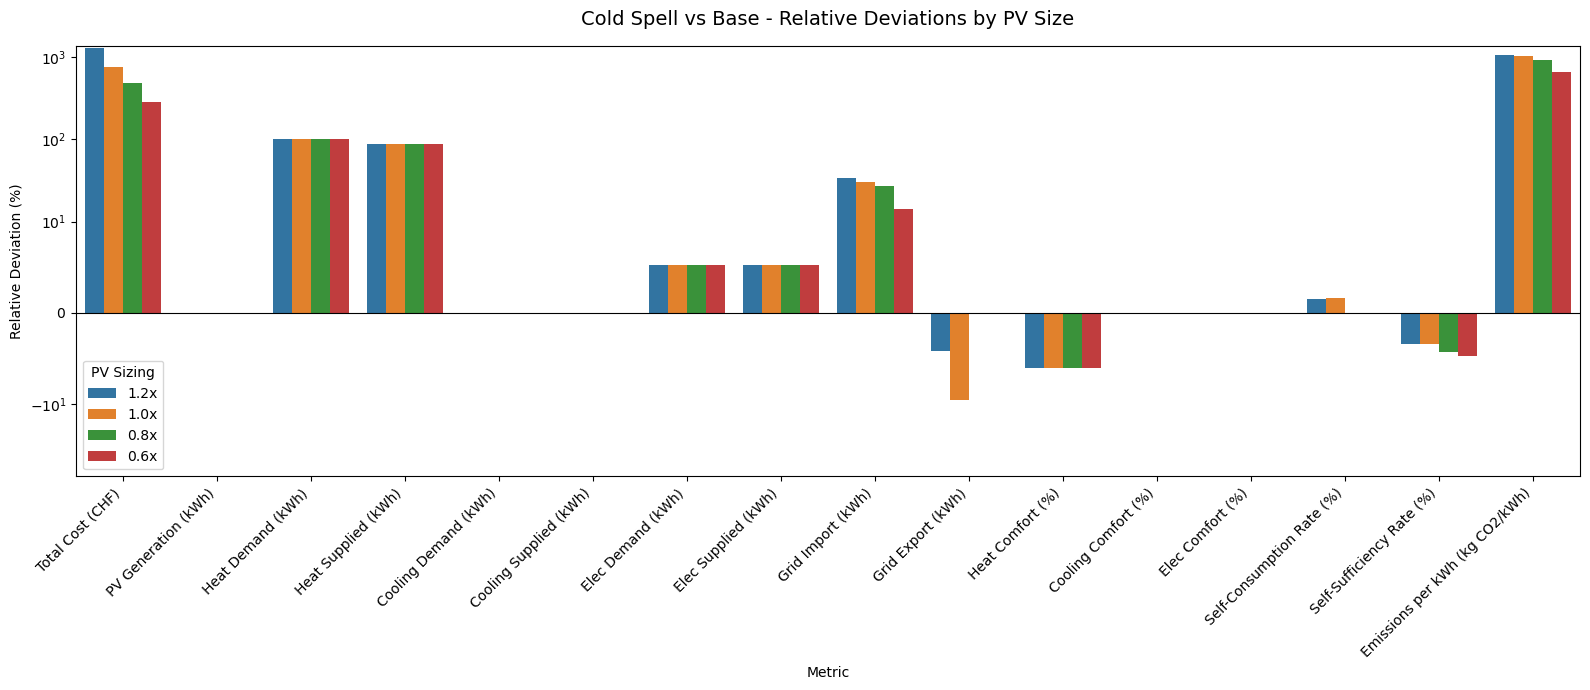

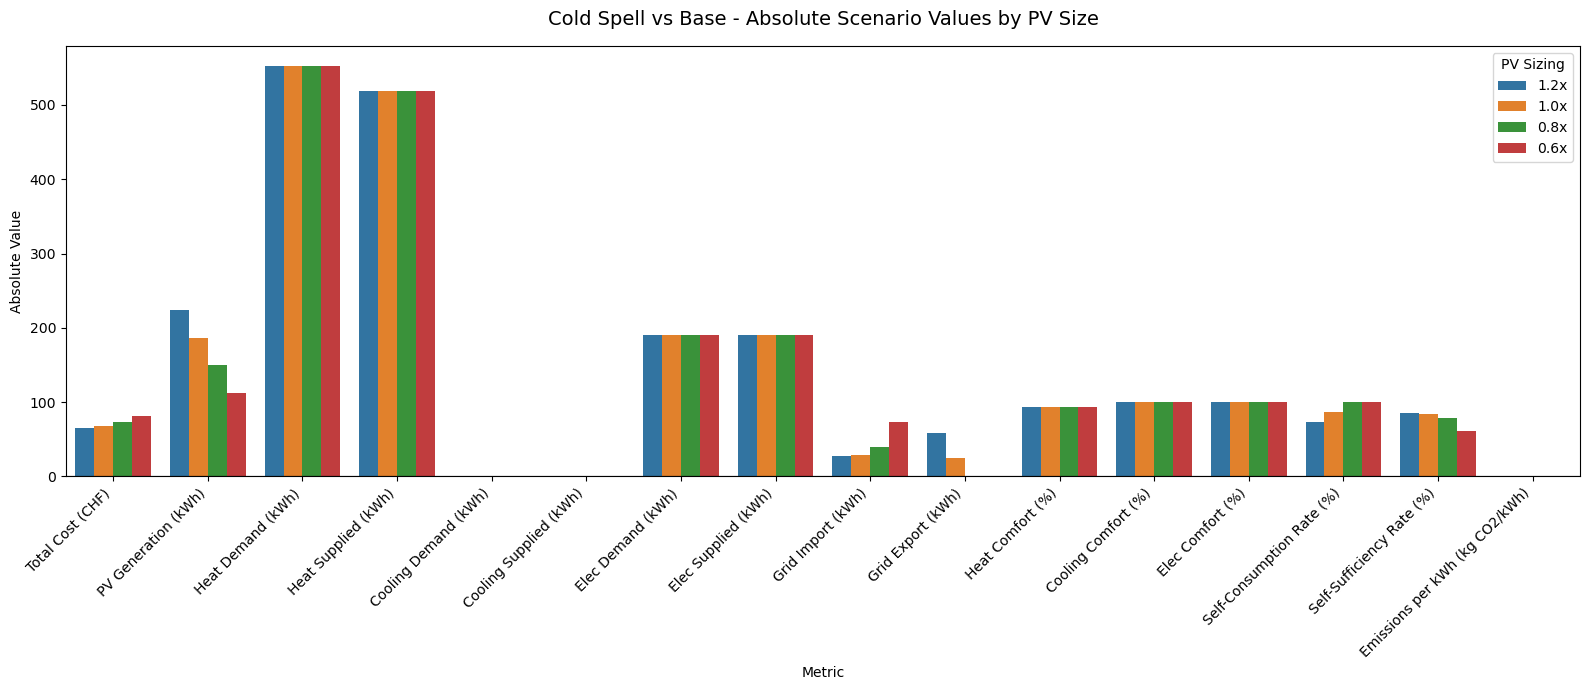

In [11]:
show_sweep_comparison(sweep_results_cs, 'Cold Spell vs Base')


## Coldspell combined with a snow blizzard

Assuming PV has no snow removal system nor human removal of snow, depending on the thickness of the snow and lack of sun we can assume low to no Production from the PV side. To simplify the simulation we assume the worst case scenario assume no Production form PV.



RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=3.4499999999999997
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump    : Capacity=1.5    Efficiency=1.75  
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=3.4499999999999997
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=0.0    Ef

,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),4.59,81.04,+76.45,+1665.73%
1,PV Generation (kWh),224.23,0.00,-224.23,-100.00%
2,Heat Demand (kWh),276.00,331.20,+55.20,+20.00%
3,Heat Supplied (kWh),276.00,331.20,+55.20,+20.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),180.86,190.29,+9.43,+5.21%
7,Elec Supplied (kWh),180.86,190.29,+9.43,+5.21%
8,Grid Import (kWh),20.41,184.59,+164.18,+804.54%
9,Grid Export (kWh),61.50,0.00,-61.50,-100.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),7.93,81.04,+73.11,+921.74%
1,PV Generation (kWh),186.86,0.00,-186.86,-100.00%
2,Heat Demand (kWh),276.00,331.20,+55.20,+20.00%
3,Heat Supplied (kWh),276.00,331.20,+55.20,+20.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),180.86,190.29,+9.43,+5.21%
7,Elec Supplied (kWh),180.86,190.29,+9.43,+5.21%
8,Grid Import (kWh),22.56,184.59,+162.02,+718.10%
9,Grid Export (kWh),27.01,0.00,-27.01,-100.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),12.39,81.04,+68.65,+554.08%
1,PV Generation (kWh),149.49,0.00,-149.49,-100.00%
2,Heat Demand (kWh),276.00,331.20,+55.20,+20.00%
3,Heat Supplied (kWh),276.00,331.20,+55.20,+20.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),180.86,190.29,+9.43,+5.21%
7,Elec Supplied (kWh),180.86,190.29,+9.43,+5.21%
8,Grid Import (kWh),31.07,184.59,+153.51,+494.05%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),21.42,81.04,+59.62,+278.40%
1,PV Generation (kWh),112.11,0.00,-112.11,-100.00%
2,Heat Demand (kWh),276.00,331.20,+55.20,+20.00%
3,Heat Supplied (kWh),276.00,331.20,+55.20,+20.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),180.86,190.29,+9.43,+5.21%
7,Elec Supplied (kWh),180.86,190.29,+9.43,+5.21%
8,Grid Import (kWh),64.50,184.59,+120.08,+186.16%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),81.04,81.04,81.04,81.04
12,PV Generation (kWh),0.00,0.00,0.00,0.00
10,Heat Demand (kWh),331.20,331.20,331.20,331.20
11,Heat Supplied (kWh),331.20,331.20,331.20,331.20
1,Cooling Demand (kWh),0.00,0.00,0.00,0.00
2,Cooling Supplied (kWh),0.00,0.00,0.00,0.00
4,Elec Demand (kWh),190.29,190.29,190.29,190.29
5,Elec Supplied (kWh),190.29,190.29,190.29,190.29
8,Grid Import (kWh),184.59,184.59,184.59,184.59
7,Grid Export (kWh),0.00,0.00,0.00,0.00


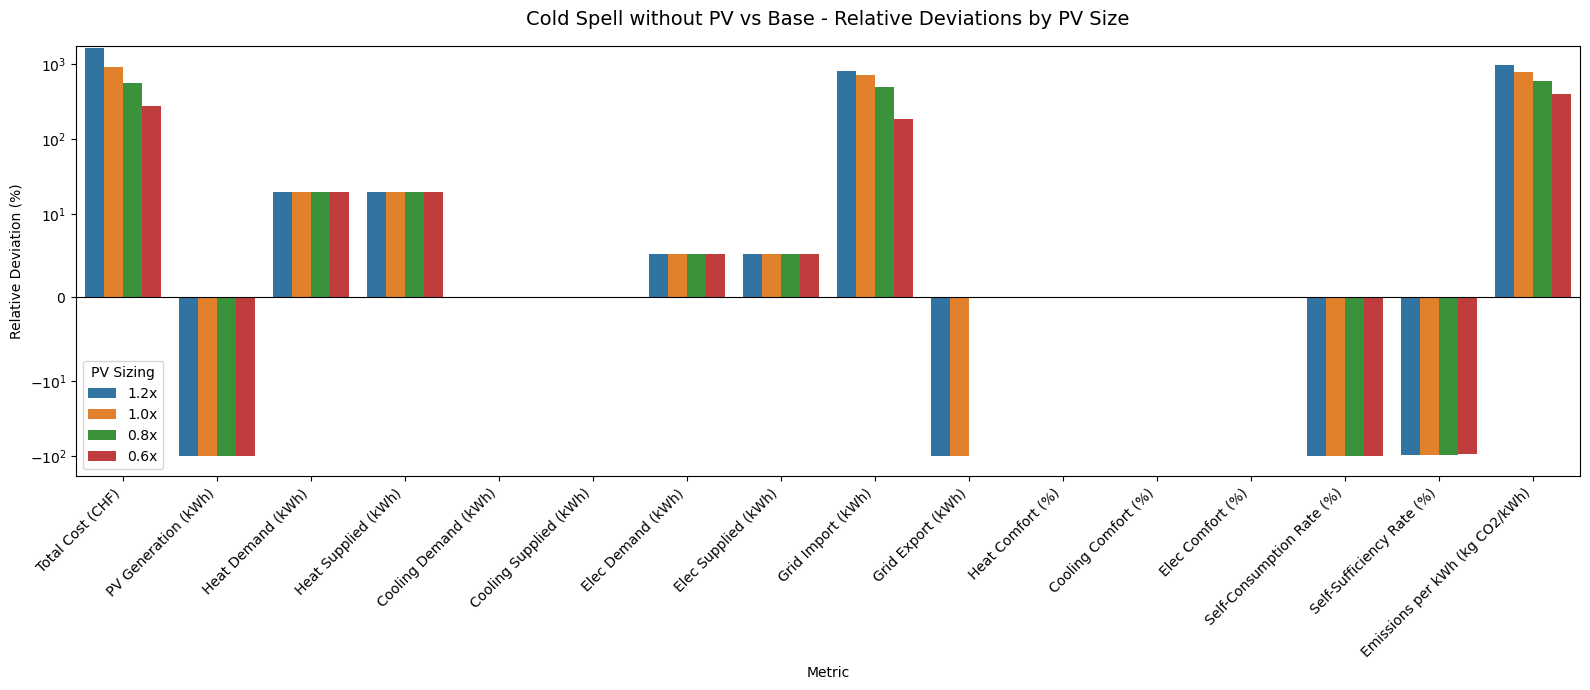

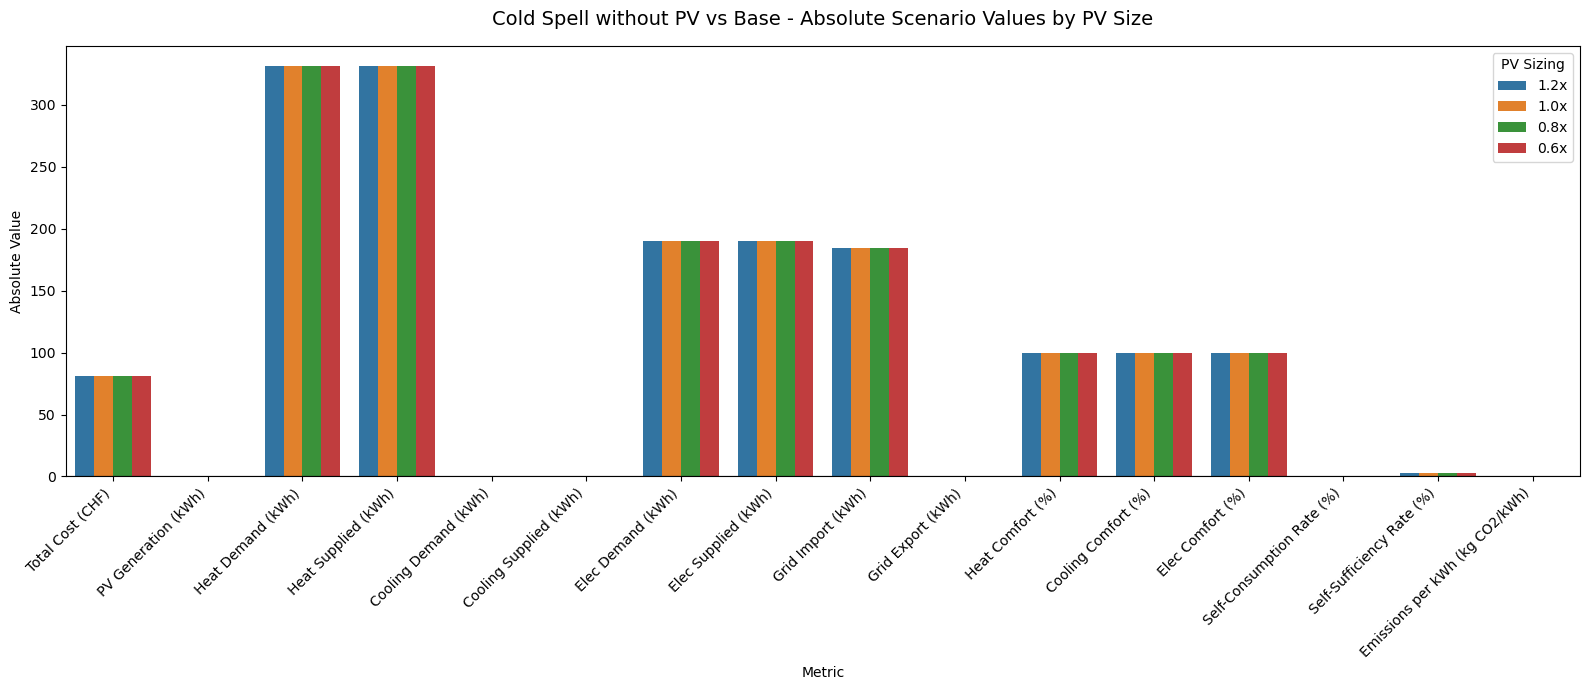

In [22]:
sweep_results_cs_no_PV = run_pv_sweep_scenario(
    duration_days           = 4,     # e.g. 4-day cold spell
    season                  = 'winter',  # <--- set season to winter
    pv_factor               = 0.0,   # less sun in winter
    battery_factor          = 1.0,
    heat_demand_factor      = 1.2,   # 1.2x heat demand
    cooling_demand_factor   = 0.0,   # no cooling needed
    elec_demand_factor      = 1.0,   # slightly more elec (lights etc.)
    hp_capacity_factor      = 0.5,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)

show_sweep_comparison(sweep_results_cs_no_PV, 'Cold Spell without PV vs Base')

## Coldspell combined with a black out

It is not to exclude that no blackout could occur during a Coldspell.


RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=3.4499999999999997
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=7.186813186813186 Efficiency=1.0   
HeatPump    : Capacity=1.5    Efficiency=1.75  
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=3.4499999999999997
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacit

,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),0.83,6.62,+5.79,+699.61%
1,PV Generation (kWh),56.06,56.06,+0.00,+0.00%
2,Heat Demand (kWh),69.00,82.80,+13.80,+20.00%
3,Heat Supplied (kWh),69.00,82.80,+13.80,+20.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),45.86,47.57,+1.71,+3.74%
7,Elec Supplied (kWh),45.86,42.13,-3.73,-8.13%
8,Grid Import (kWh),3.73,0.00,-3.73,-100.00%
9,Grid Export (kWh),14.73,14.73,+0.00,+0.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),1.52,7.31,+5.79,+381.64%
1,PV Generation (kWh),46.71,46.71,+0.00,+0.00%
2,Heat Demand (kWh),69.00,82.80,+13.80,+20.00%
3,Heat Supplied (kWh),69.00,82.80,+13.80,+20.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),45.86,47.57,+1.71,+3.74%
7,Elec Supplied (kWh),45.86,42.13,-3.73,-8.13%
8,Grid Import (kWh),3.73,0.00,-3.73,-100.00%
9,Grid Export (kWh),6.11,6.11,+0.00,+0.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),2.23,7.80,+5.57,+249.06%
1,PV Generation (kWh),37.37,37.37,+0.00,+0.00%
2,Heat Demand (kWh),69.00,82.80,+13.80,+20.00%
3,Heat Supplied (kWh),69.00,82.80,+13.80,+20.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),45.86,47.57,+1.71,+3.74%
7,Elec Supplied (kWh),45.86,41.28,-4.57,-9.97%
8,Grid Import (kWh),4.57,0.00,-4.57,-100.00%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),4.36,7.80,+3.44,+79.04%
1,PV Generation (kWh),28.03,28.03,+0.00,+0.00%
2,Heat Demand (kWh),69.00,82.80,+13.80,+20.00%
3,Heat Supplied (kWh),69.00,82.80,+13.80,+20.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),45.86,47.57,+1.71,+3.74%
7,Elec Supplied (kWh),45.86,33.43,-12.43,-27.11%
8,Grid Import (kWh),12.43,0.00,-12.43,-100.00%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),6.62,7.31,7.80,7.80
12,PV Generation (kWh),56.06,46.71,37.37,28.03
10,Heat Demand (kWh),82.80,82.80,82.80,82.80
11,Heat Supplied (kWh),82.80,82.80,82.80,82.80
1,Cooling Demand (kWh),0.00,0.00,0.00,0.00
2,Cooling Supplied (kWh),0.00,0.00,0.00,0.00
4,Elec Demand (kWh),47.57,47.57,47.57,47.57
5,Elec Supplied (kWh),42.13,42.13,41.28,33.43
8,Grid Import (kWh),0.00,0.00,0.00,0.00
7,Grid Export (kWh),14.73,6.11,0.00,0.00


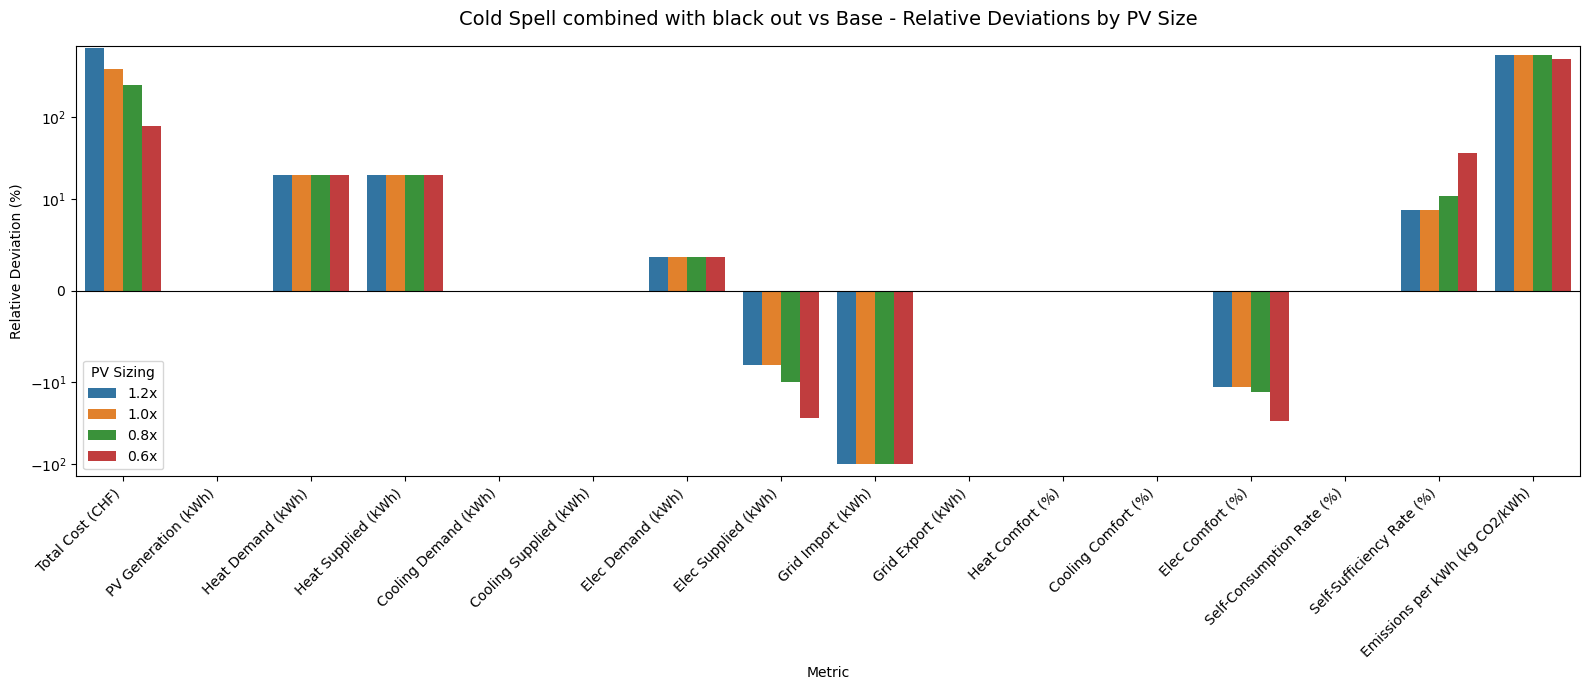

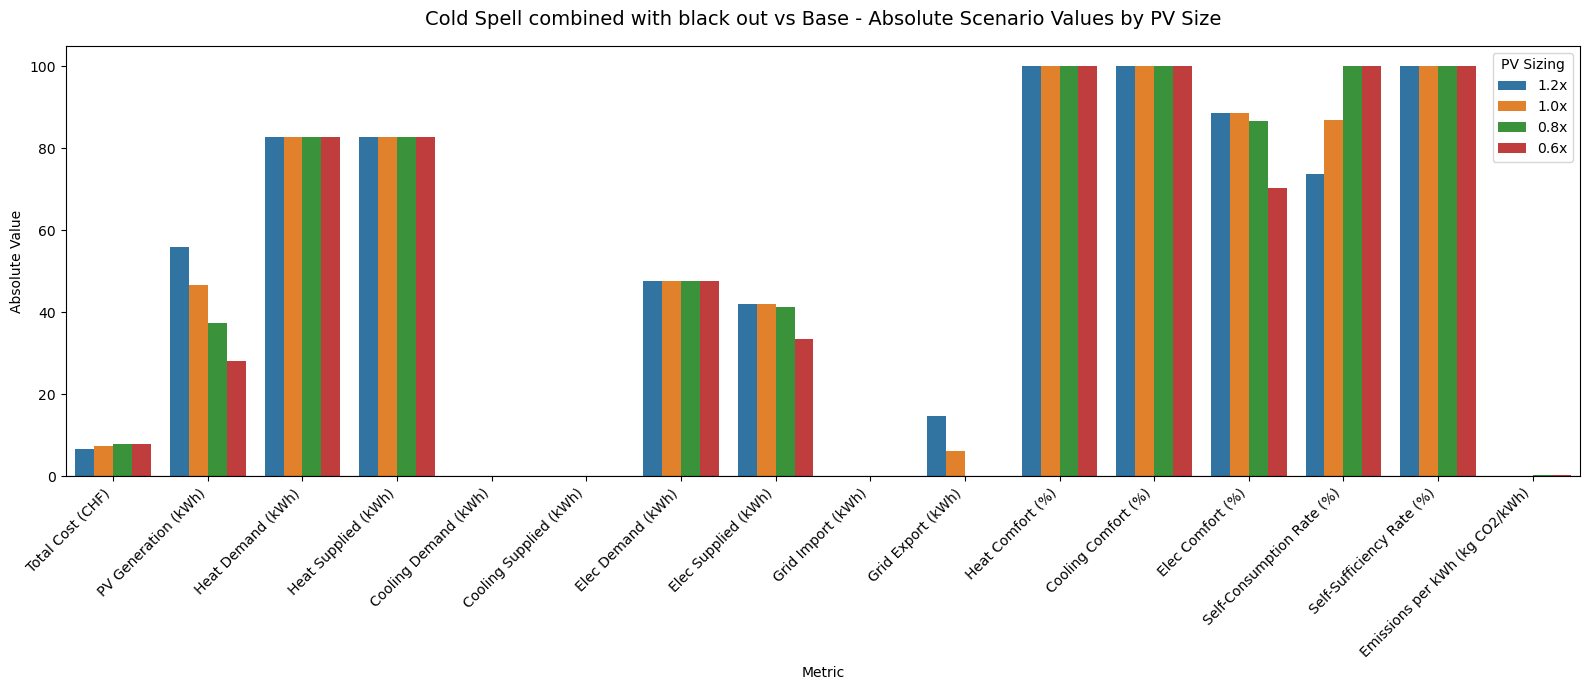

In [24]:
sweep_results_cs_bo = run_pv_sweep_scenario(
    duration_days           = 1,     # e.g. 4-day cold spell
    season                  = 'winter',  # <--- set season to winter
    pv_factor               = 1.0,   # less sun in winter
    battery_factor          = 1.0,
    heat_demand_factor      = 1.2,   # 1.2x heat demand
    cooling_demand_factor   = 0.0,   # no cooling needed
    elec_demand_factor      = 1.0,   # slightly more elec (lights etc.)
    hp_capacity_factor      = 0.5,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = True,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)
show_sweep_comparison(sweep_results_cs_bo, 'Cold Spell combined with black out vs Base')

## PV Breaks
what happens when PV breaks

In [12]:
sweep_results_no_pv_s = run_pv_sweep_scenario(
    duration_days           = 30,
    season                  = 'summer',  # <--- set season to summer
    pv_factor               = 0,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 1.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)



RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=2.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=0.35  
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=2.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump


---  Broken PV vs Base in Summer ---

PV Sizing: 1.2x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),-18.52,366.20,+384.72,+2076.96%
1,PV Generation (kWh),1634.40,0.00,-1634.40,-100.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,1440.00,+0.00,+0.00%
5,Cooling Supplied (kWh),1440.00,1440.00,+0.00,+0.00%
6,Elec Demand (kWh),1365.50,1362.00,-3.50,-0.26%
7,Elec Supplied (kWh),1365.50,1362.00,-3.50,-0.26%
8,Grid Import (kWh),2.64,1356.30,+1353.66,+51219.46%
9,Grid Export (kWh),240.46,0.00,-240.46,-100.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),9.13,366.20,+357.08,+3912.88%
1,PV Generation (kWh),1362.00,0.00,-1362.00,-100.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,1440.00,+0.00,+0.00%
5,Cooling Supplied (kWh),1440.00,1440.00,+0.00,+0.00%
6,Elec Demand (kWh),1365.50,1362.00,-3.50,-0.26%
7,Elec Supplied (kWh),1365.50,1362.00,-3.50,-0.26%
8,Grid Import (kWh),33.80,1356.30,+1322.50,+3912.88%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),75.89,366.20,+290.31,+382.56%
1,PV Generation (kWh),1089.60,0.00,-1089.60,-100.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,1440.00,+0.00,+0.00%
5,Cooling Supplied (kWh),1440.00,1440.00,+0.00,+0.00%
6,Elec Demand (kWh),1365.50,1362.00,-3.50,-0.26%
7,Elec Supplied (kWh),1365.50,1362.00,-3.50,-0.26%
8,Grid Import (kWh),281.06,1356.30,+1075.24,+382.56%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),145.75,366.20,+220.45,+151.25%
1,PV Generation (kWh),817.20,0.00,-817.20,-100.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,1440.00,+0.00,+0.00%
5,Cooling Supplied (kWh),1440.00,1440.00,+0.00,+0.00%
6,Elec Demand (kWh),1362.72,1362.00,-0.72,-0.05%
7,Elec Supplied (kWh),1362.72,1362.00,-0.72,-0.05%
8,Grid Import (kWh),539.82,1356.30,+816.48,+151.25%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),366.20,366.20,366.20,366.20
12,PV Generation (kWh),0.00,0.00,0.00,0.00
10,Heat Demand (kWh),252.00,252.00,252.00,252.00
11,Heat Supplied (kWh),252.00,252.00,252.00,252.00
1,Cooling Demand (kWh),1440.00,1440.00,1440.00,1440.00
2,Cooling Supplied (kWh),1440.00,1440.00,1440.00,1440.00
4,Elec Demand (kWh),1362.00,1362.00,1362.00,1362.00
5,Elec Supplied (kWh),1362.00,1362.00,1362.00,1362.00
8,Grid Import (kWh),1356.30,1356.30,1356.30,1356.30
7,Grid Export (kWh),0.00,0.00,0.00,0.00


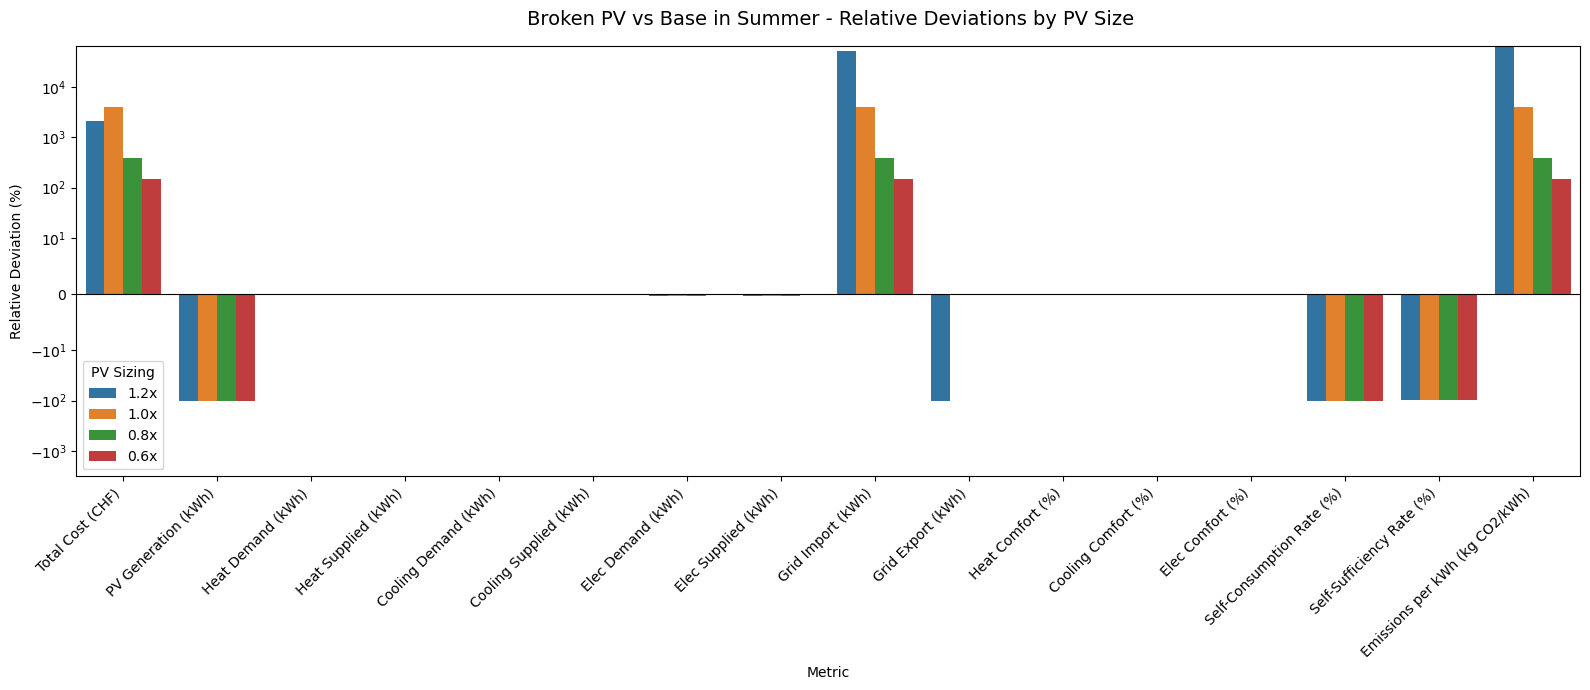

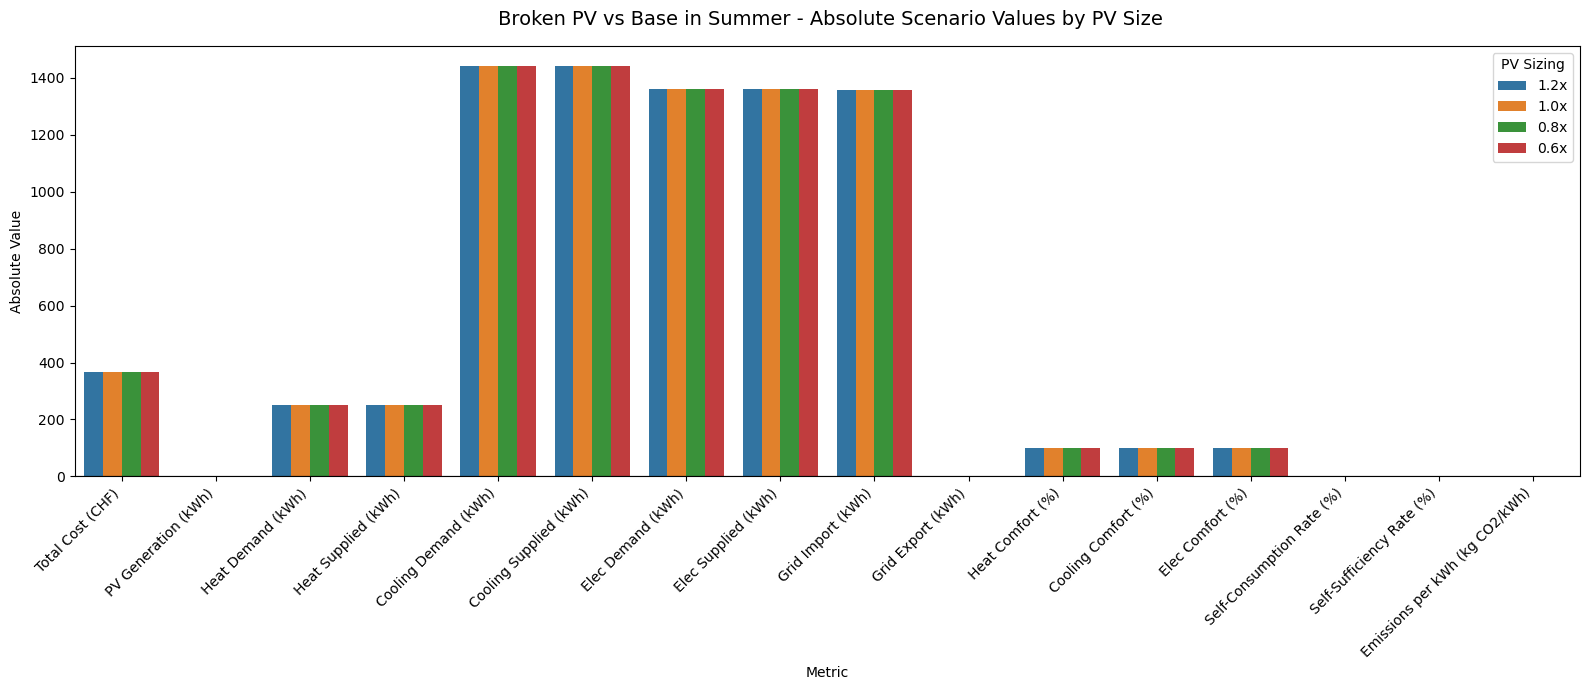

In [13]:
show_sweep_comparison(sweep_results_no_pv_s, ' Broken PV vs Base in Summer')

In [14]:
sweep_results_no_pv_w = run_pv_sweep_scenario(
    duration_days           = 30,
    season                  = 'winter',  # <--- set season to summer
    pv_factor               = 0,
    battery_factor          = 1.0,
    heat_demand_factor      = 1.0,   # 2.0 = coldspell
    cooling_demand_factor   = 1.0,   # 2.0 = heatwave
    elec_demand_factor      = 1.0,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 1.0,
    grid_export_price_factor = 1.0,
)


RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.27   ExportPrice=0.08  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.875 
Elec        : Avg Demand=1.125 
Cooling     : Avg Demand=0.0   
PV          : Capacity=0.0    Efficiency=1.0   
HeatPump


--- Blackout vs Base in Summer ---

PV Sizing: 1.2x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),-18.52,366.20,+384.72,+2076.96%
1,PV Generation (kWh),1634.40,0.00,-1634.40,-100.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,1440.00,+0.00,+0.00%
5,Cooling Supplied (kWh),1440.00,1440.00,+0.00,+0.00%
6,Elec Demand (kWh),1365.50,1362.00,-3.50,-0.26%
7,Elec Supplied (kWh),1365.50,1362.00,-3.50,-0.26%
8,Grid Import (kWh),2.64,1356.30,+1353.66,+51219.46%
9,Grid Export (kWh),240.46,0.00,-240.46,-100.00%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),9.13,366.20,+357.08,+3912.88%
1,PV Generation (kWh),1362.00,0.00,-1362.00,-100.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,1440.00,+0.00,+0.00%
5,Cooling Supplied (kWh),1440.00,1440.00,+0.00,+0.00%
6,Elec Demand (kWh),1365.50,1362.00,-3.50,-0.26%
7,Elec Supplied (kWh),1365.50,1362.00,-3.50,-0.26%
8,Grid Import (kWh),33.80,1356.30,+1322.50,+3912.88%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),75.89,366.20,+290.31,+382.56%
1,PV Generation (kWh),1089.60,0.00,-1089.60,-100.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,1440.00,+0.00,+0.00%
5,Cooling Supplied (kWh),1440.00,1440.00,+0.00,+0.00%
6,Elec Demand (kWh),1365.50,1362.00,-3.50,-0.26%
7,Elec Supplied (kWh),1365.50,1362.00,-3.50,-0.26%
8,Grid Import (kWh),281.06,1356.30,+1075.24,+382.56%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),145.75,366.20,+220.45,+151.25%
1,PV Generation (kWh),817.20,0.00,-817.20,-100.00%
2,Heat Demand (kWh),252.00,252.00,+0.00,+0.00%
3,Heat Supplied (kWh),252.00,252.00,+0.00,+0.00%
4,Cooling Demand (kWh),1440.00,1440.00,+0.00,+0.00%
5,Cooling Supplied (kWh),1440.00,1440.00,+0.00,+0.00%
6,Elec Demand (kWh),1362.72,1362.00,-0.72,-0.05%
7,Elec Supplied (kWh),1362.72,1362.00,-0.72,-0.05%
8,Grid Import (kWh),539.82,1356.30,+816.48,+151.25%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),366.20,366.20,366.20,366.20
12,PV Generation (kWh),0.00,0.00,0.00,0.00
10,Heat Demand (kWh),252.00,252.00,252.00,252.00
11,Heat Supplied (kWh),252.00,252.00,252.00,252.00
1,Cooling Demand (kWh),1440.00,1440.00,1440.00,1440.00
2,Cooling Supplied (kWh),1440.00,1440.00,1440.00,1440.00
4,Elec Demand (kWh),1362.00,1362.00,1362.00,1362.00
5,Elec Supplied (kWh),1362.00,1362.00,1362.00,1362.00
8,Grid Import (kWh),1356.30,1356.30,1356.30,1356.30
7,Grid Export (kWh),0.00,0.00,0.00,0.00


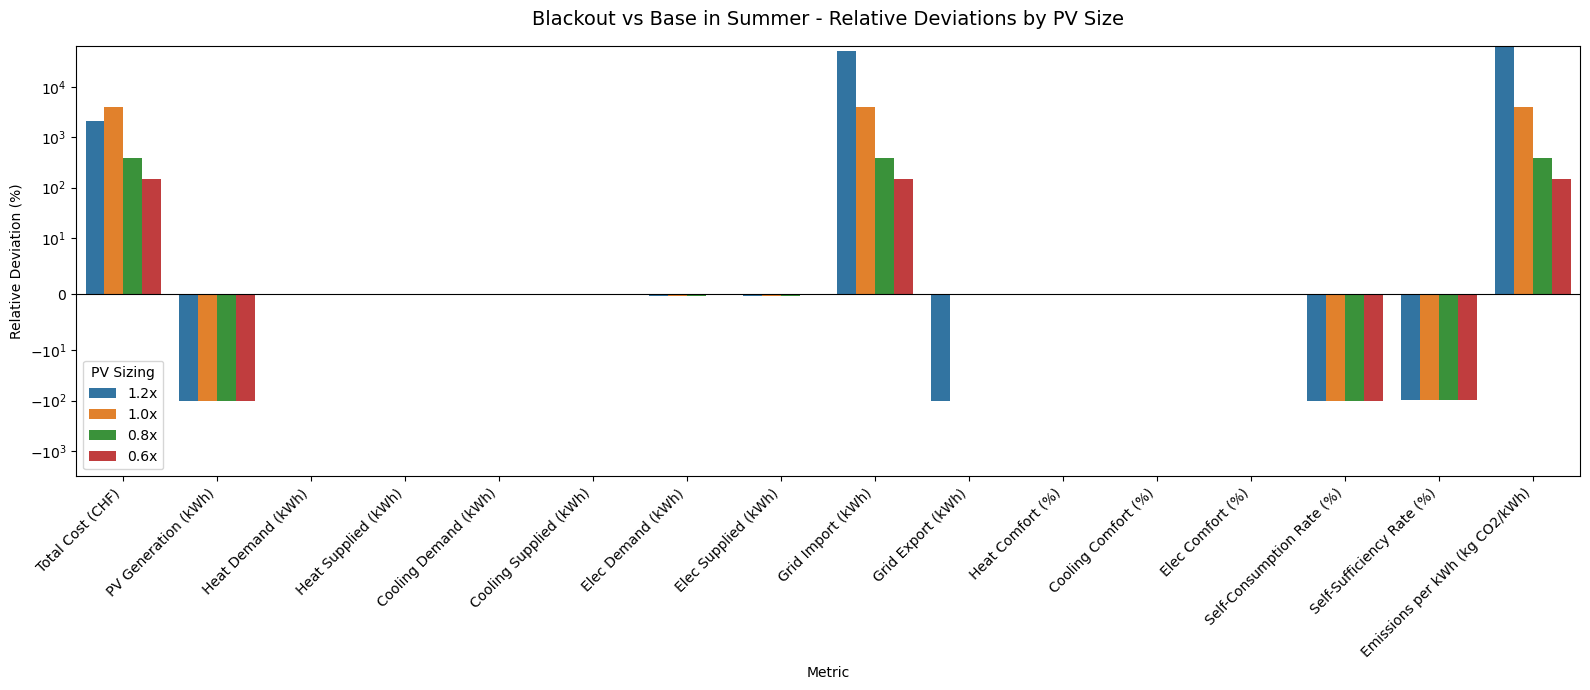

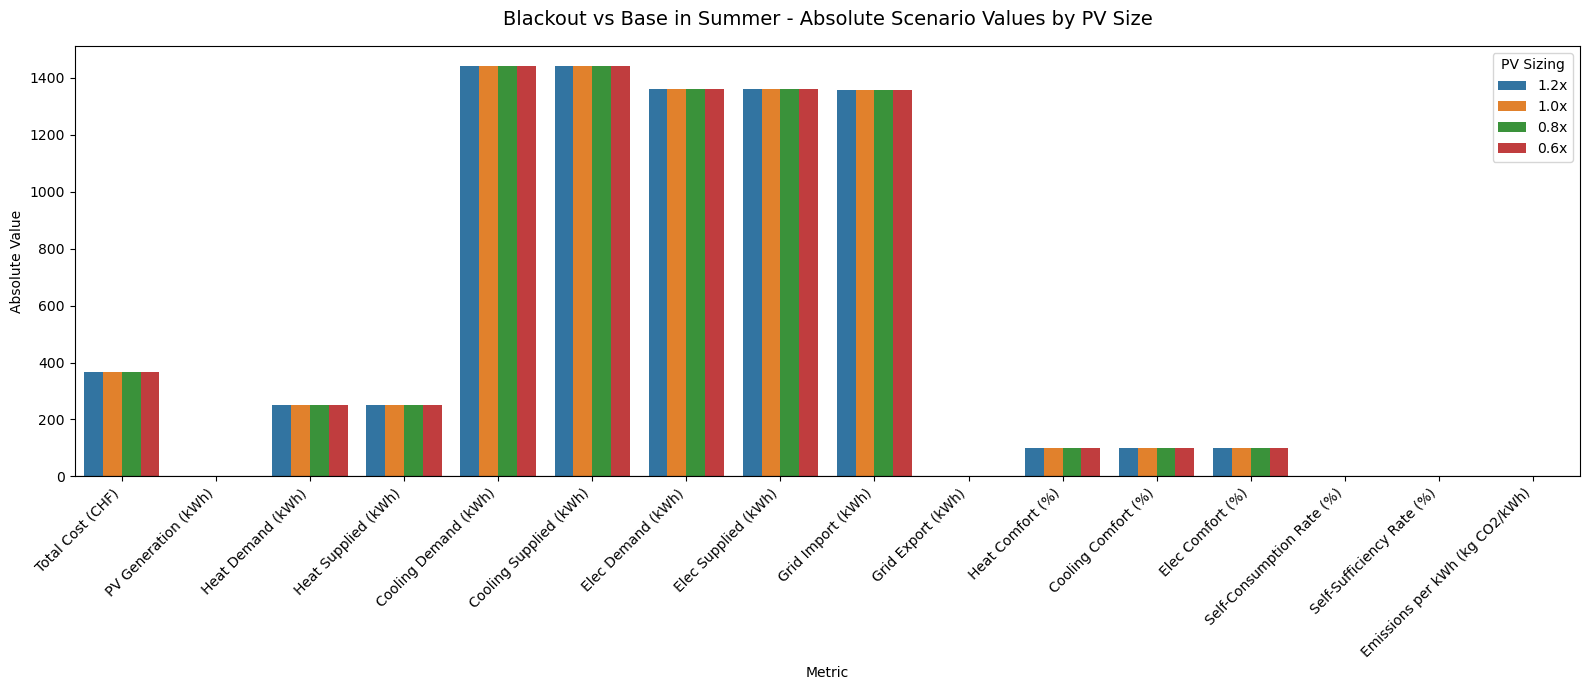

In [15]:
show_sweep_comparison(sweep_results_no_pv_s, 'Blackout vs Base in Summer')

## Economic Depression
Increased Electricity and Gas prices


RUNNING SWEEP: PV Sizing Factor = 1.2x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.5875
Elec        : Avg Demand=1.0125000000000002
Cooling     : Avg Demand=0.0   
PV          : Capacity=7.186813186813186 Efficiency=1.0   
HeatPump    : Capacity=3.0    Efficiency=3.5   
GasBoiler   : Capacity=5.0    Efficiency=0.9   
Chiller     : Capacity=4.0    Efficiency=3.0   
Battery     : Capacity=10.0   MaxCharge=5.0   
HeatStorage : Capacity=5.0    MaxCharge=3.0   
Grid        : ImportPrice=0.81   ExportPrice=0.24  
--------------------------------------------------


RUNNING SWEEP: PV Sizing Factor = 1.0x Base Demand

--------------------------------------------------
CURRENT SYSTEM PARAMETERS
--------------------------------------------------
Heat        : Avg Demand=2.5875
Elec        : Avg Demand=1.0125000000000002
Cooling     : Avg Demand=0.0   
PV          : Capacit

,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),124.96,-41.49,-166.44,-133.20%
1,PV Generation (kWh),5605.71,5605.71,+0.00,+0.00%
2,Heat Demand (kWh),6900.00,6210.00,-690.00,-10.00%
3,Heat Supplied (kWh),6900.00,6210.00,-690.00,-10.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),4500.86,4102.36,-398.50,-8.85%
7,Elec Supplied (kWh),4500.86,4102.36,-398.50,-8.85%
8,Grid Import (kWh),554.10,412.30,-141.81,-25.59%
9,Grid Export (kWh),1558.16,1814.38,+256.22,+16.44%



PV Sizing: 1.0x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),213.16,223.12,+9.96,+4.67%
1,PV Generation (kWh),4671.43,4671.43,+0.00,+0.00%
2,Heat Demand (kWh),6900.00,6210.00,-690.00,-10.00%
3,Heat Supplied (kWh),6900.00,6210.00,-690.00,-10.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),4500.86,4102.36,-398.50,-8.85%
7,Elec Supplied (kWh),4500.86,4102.36,-398.50,-8.85%
8,Grid Import (kWh),625.25,483.45,-141.81,-22.68%
9,Grid Export (kWh),695.74,951.96,+256.22,+36.83%



PV Sizing: 0.8x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),330.67,488.20,+157.53,+47.64%
1,PV Generation (kWh),3737.14,3737.14,+0.00,+0.00%
2,Heat Demand (kWh),6900.00,6210.00,-690.00,-10.00%
3,Heat Supplied (kWh),6900.00,6210.00,-690.00,-10.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),4500.86,4102.98,-397.88,-8.84%
7,Elec Supplied (kWh),4500.86,4102.98,-397.88,-8.84%
8,Grid Import (kWh),854.32,555.18,-299.14,-35.02%
9,Grid Export (kWh),0.00,89.56,+89.56,+nan%



PV Sizing: 0.6x Demand


,Metric,Base,Scenario,Abs. Diff,Rel. Dev. (%)
0,Total Cost (CHF),567.33,1149.95,+582.62,+102.70%
1,PV Generation (kWh),2802.86,2802.86,+0.00,+0.00%
2,Heat Demand (kWh),6900.00,6210.00,-690.00,-10.00%
3,Heat Supplied (kWh),6900.00,6210.00,-690.00,-10.00%
4,Cooling Demand (kWh),0.00,0.00,+0.00,+0.00%
5,Cooling Supplied (kWh),0.00,0.00,+0.00,+0.00%
6,Elec Demand (kWh),4500.86,4102.71,-398.14,-8.85%
7,Elec Supplied (kWh),4500.86,4102.71,-398.14,-8.85%
8,Grid Import (kWh),1730.85,1345.62,-385.23,-22.26%
9,Grid Export (kWh),0.00,0.00,+0.00,+0.00%



--- Absolute Comparison (Scenario Values) ---


PV Sizing,Metric,1.2x,1.0x,0.8x,0.6x
15,Total Cost (CHF),-41.49,223.12,488.20,1149.95
12,PV Generation (kWh),5605.71,4671.43,3737.14,2802.86
10,Heat Demand (kWh),6210.00,6210.00,6210.00,6210.00
11,Heat Supplied (kWh),6210.00,6210.00,6210.00,6210.00
1,Cooling Demand (kWh),0.00,0.00,0.00,0.00
2,Cooling Supplied (kWh),0.00,0.00,0.00,0.00
4,Elec Demand (kWh),4102.36,4102.36,4102.98,4102.71
5,Elec Supplied (kWh),4102.36,4102.36,4102.98,4102.71
8,Grid Import (kWh),412.30,483.45,555.18,1345.62
7,Grid Export (kWh),1814.38,951.96,89.56,0.00


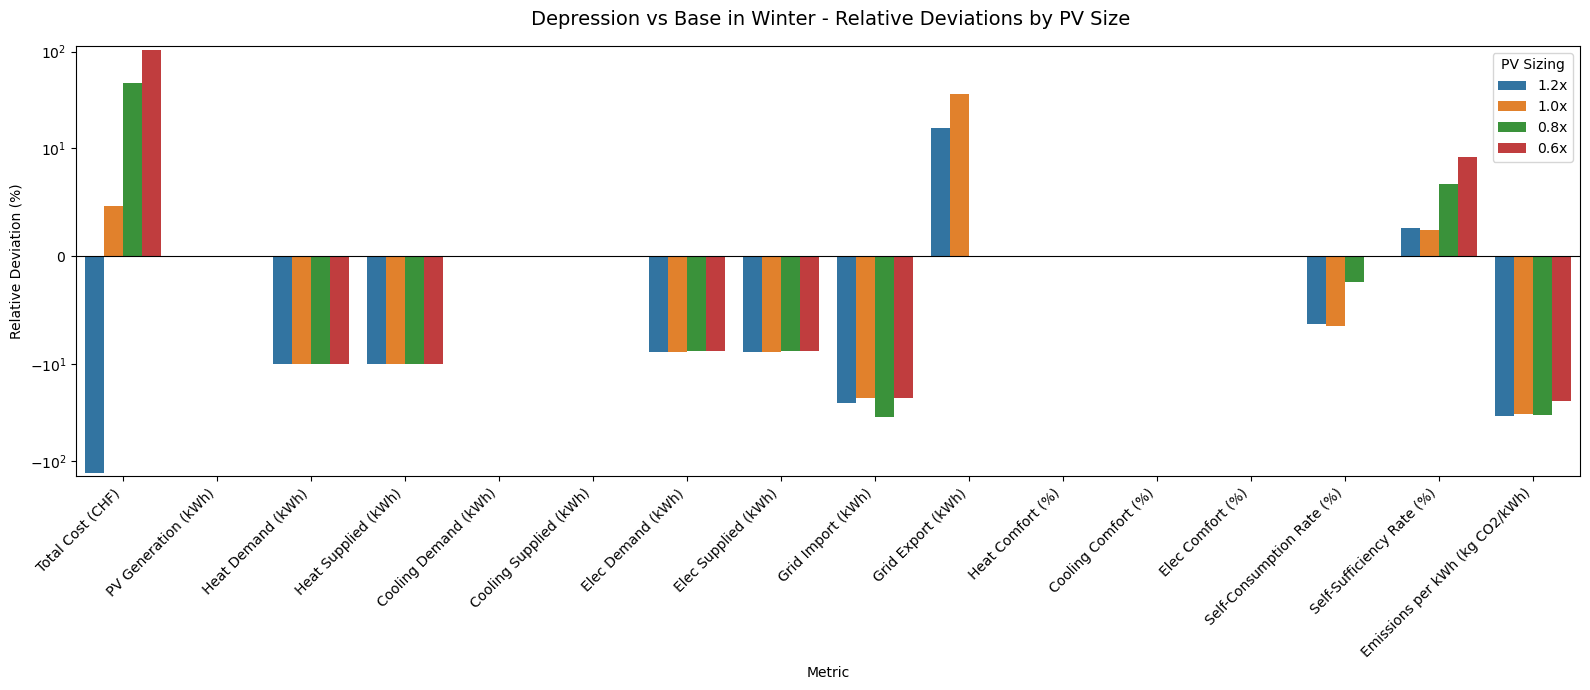

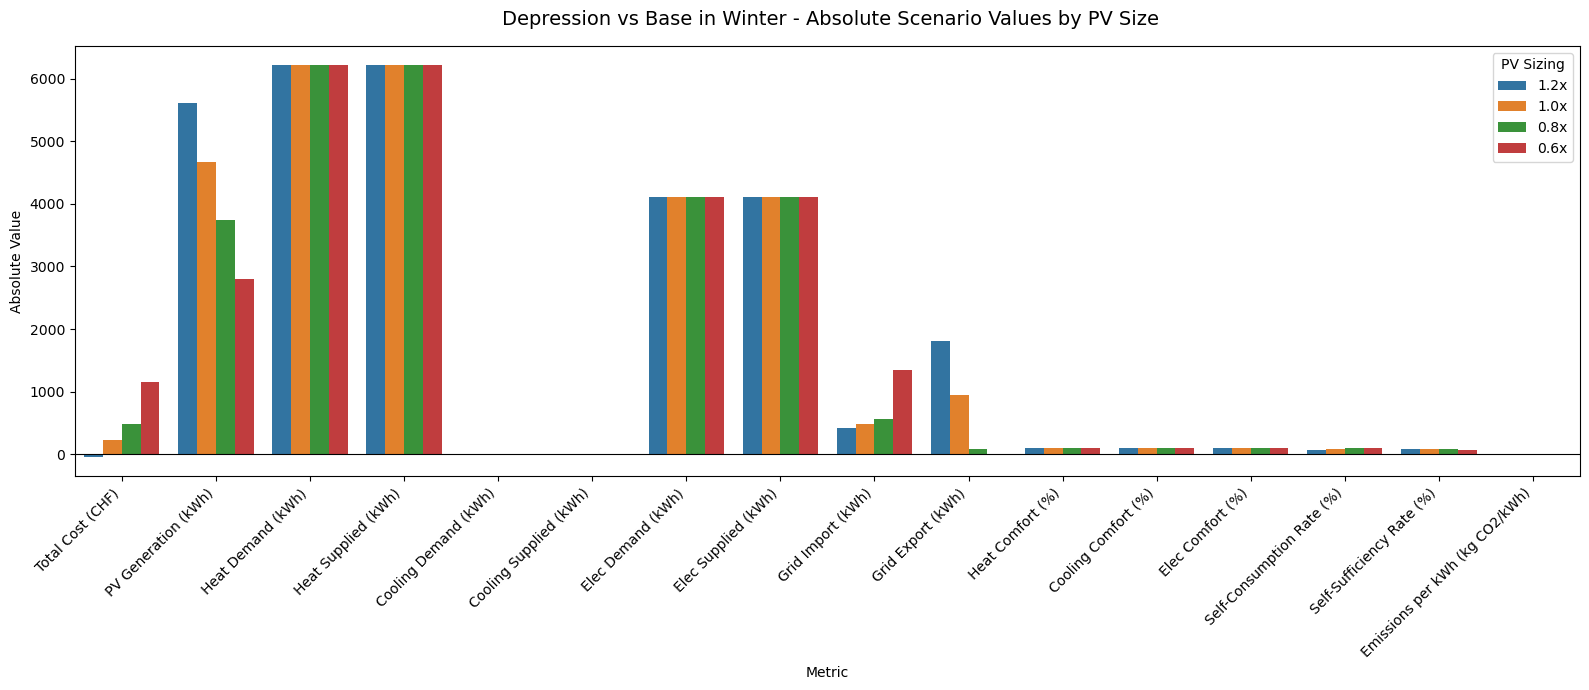

In [20]:
sweep_results_depression = run_pv_sweep_scenario(
    duration_days           = 100,
    season                  = 'winter',  # <--- set season to summer
    pv_factor               = 1,
    battery_factor          = 1.0,
    heat_demand_factor      = 0.90,   # 2.0 = coldspell
    cooling_demand_factor   = 1.0,   # 2.0 = heatwave
    elec_demand_factor      = 0.9,
    hp_capacity_factor      = 1.0,
    chiller_capacity_factor = 1.0,
    boiler_capacity_factor  = 1.0,
    heat_storage_factor     = 1.0,
    black_out_factor        = False,
    grid_import_price_factor = 3.0,
    grid_export_price_factor = 3.0,
)

show_sweep_comparison(sweep_results_depression, ' Depression vs Base in Winter')